# Delay Classification — Random Forest (Binary)
Single model, clean 16-feature set, saves model + scaler + encoders to `../models/`

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score, f1_score
)

os.makedirs('../models',  exist_ok=True)
os.makedirs('../Results', exist_ok=True)

print('[OK] Imports done')

[OK] Imports done


In [3]:
# ============================================================
# STEP 1 — LOAD DATASET
# ============================================================

df = pd.read_csv(r'../Data/dataset_with_weather_features.csv')
print(f'[OK] Dataset loaded! Shape: {df.shape}')

[OK] Dataset loaded! Shape: (25000, 37)


In [4]:
# ============================================================
# STEP 2 — MINIMAL FEATURE ENGINEERING
# (only time features needed for the 16-feature set)
# ============================================================

df['order_ts_recon'] = pd.to_datetime(
    df['order_ts_recon'], format='%d-%m-%Y %H.%M', errors='coerce'
)

df['order_hour']      = df['order_ts_recon'].dt.hour.fillna(0).astype(int)
df['order_dayofweek'] = df['order_ts_recon'].dt.dayofweek.fillna(0).astype(int)  # 0=Mon … 6=Sun
df['is_weekend']      = (df['order_dayofweek'] >= 5).astype(int)

# Clean required numeric columns
df['distance_km']       = df['distance_km'].replace(0, np.nan).fillna(df['distance_km'].median())
df['package_weight_kg'] = df['package_weight_kg'].replace(0, np.nan).fillna(df['package_weight_kg'].median())

# Target
df['delayed'] = df['delayed'].fillna('no')

# Global NaN cleanup
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        mode_val = df[col].mode()
        df[col]  = df[col].fillna(mode_val[0] if len(mode_val) > 0 else 'Unknown')

print(f'[OK] Feature engineering done. Remaining NaNs: {df.isnull().sum().sum()}')

[OK] Feature engineering done. Remaining NaNs: 0


In [5]:
# ============================================================
# STEP 3 — DEFINE THE 16 SAFE FEATURES
#


SAFE_FEATURES = [
    'delivery_partner',
    'package_type',
    'vehicle_type',
    'delivery_mode',
    'region',
    'weather_condition',
    'distance_km',
    'package_weight_kg',
    'api_temperature',
    'api_humidity',
    'api_wind_speed',
    'bad_weather_flag_api',
    'holiday_or_weekend_transit_flag',
    'order_hour',
    'order_dayofweek',    # = order_day (0=Mon … 6=Sun)
    'is_weekend',
]

# Drop any that are missing in the dataset (safety guard)
SAFE_FEATURES = [f for f in SAFE_FEATURES if f in df.columns]
print(f'[OK] Using {len(SAFE_FEATURES)} features:')
print(SAFE_FEATURES)

[OK] Using 16 features:
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'api_temperature', 'api_humidity', 'api_wind_speed', 'bad_weather_flag_api', 'holiday_or_weekend_transit_flag', 'order_hour', 'order_dayofweek', 'is_weekend']


In [6]:
# ============================================================
# STEP 4 — ENCODE + BUILD X / y
# ============================================================

X = df[SAFE_FEATURES].copy()
y = (df['delayed'] == 'yes').astype(int)

# Label-encode all categorical columns; save encoders for inference
label_encoders = {}
for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'[OK] X shape : {X.shape}')
print(f'[OK] NaNs    : {X.isnull().sum().sum()}')
print(f'[OK] Class balance — On-Time: {(y==0).sum()} | Delayed: {(y==1).sum()}')

[OK] X shape : (25000, 16)
[OK] NaNs    : 0
[OK] Class balance — On-Time: 18331 | Delayed: 6669


In [7]:
# ============================================================
# STEP 5 — TRAIN / TEST SPLIT + SCALING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = np.nan_to_num(scaler.fit_transform(X_train), nan=0.0)
X_test_sc  = np.nan_to_num(scaler.transform(X_test),      nan=0.0)

print(f'[OK] Train : {len(y_train)} rows')
print(f'[OK] Test  : {len(y_test)} rows')

[OK] Train : 20000 rows
[OK] Test  : 5000 rows


In [23]:
# ============================================================
# STEP 6 — TRAIN RANDOM FOREST
# ============================================================

print('[RF] Training Random Forest Classifier...')

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_sc, y_train)

print('[OK] Training complete!')

[RF] Training Random Forest Classifier...
[OK] Training complete!


In [24]:
print(f'[OK] Class balance — On-Time: {(y==0).sum()} | Delayed: {(y==1).sum()}')

[OK] Class balance — On-Time: 18331 | Delayed: 6669


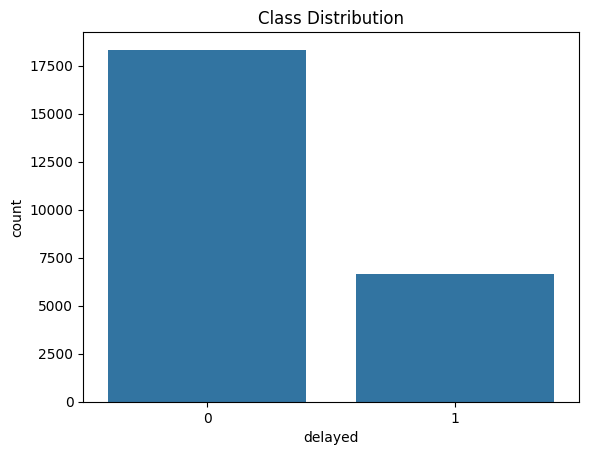

In [25]:
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

In [9]:
# ============================================================
# STEP 7 — EVALUATE
# ============================================================

y_pred  = rf_model.predict(X_test_sc)
y_proba = rf_model.predict_proba(X_test_sc)[:, 1]

acc   = accuracy_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_proba)
prauc = average_precision_score(y_test, y_proba)
f1    = f1_score(y_test, y_pred)

print(f"{'='*55}")
print(f"  RANDOM FOREST — Binary Classification Results")
print(f"{'='*55}")
print(f"  Accuracy : {acc*100:.2f}%")
print(f"  ROC-AUC  : {auc:.4f}")
print(f"  PR-AUC   : {prauc:.4f}")
print(f"  F1-Score : {f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred, target_names=['On-Time', 'Delayed']))

  RANDOM FOREST — Binary Classification Results
  Accuracy : 88.42%
  ROC-AUC  : 0.9658
  PR-AUC   : 0.9064
  F1-Score : 0.8160
              precision    recall  f1-score   support

     On-Time       0.98      0.86      0.92      3666
     Delayed       0.71      0.96      0.82      1334

    accuracy                           0.88      5000
   macro avg       0.85      0.91      0.87      5000
weighted avg       0.91      0.88      0.89      5000



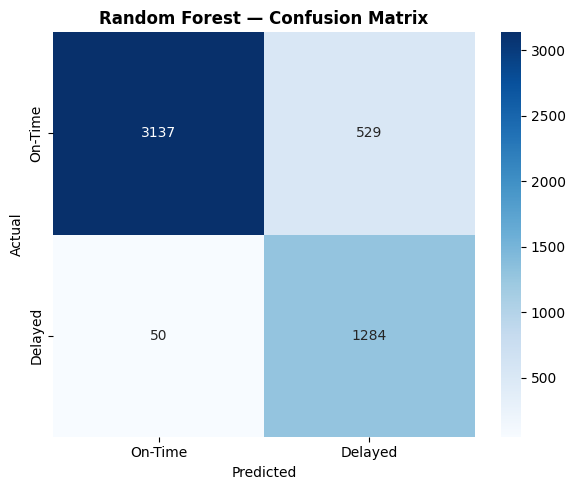

In [10]:
# ============================================================
# STEP 8 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'])
plt.title('Random Forest — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../Results/rf_classification_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

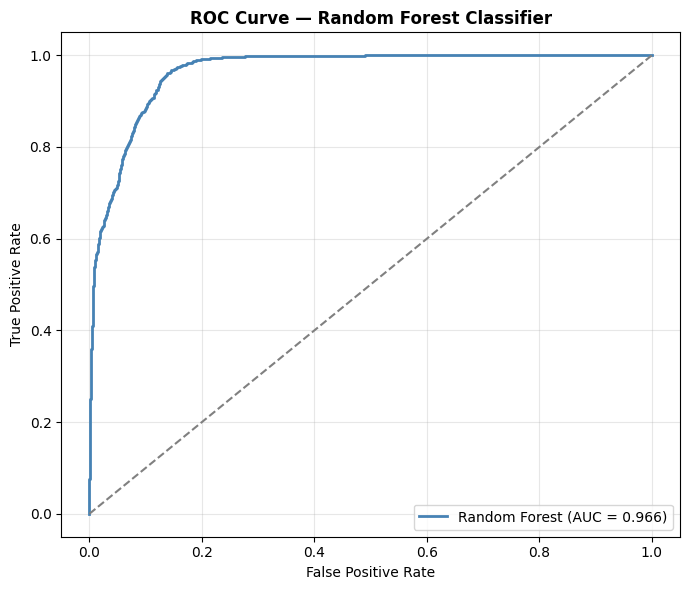

In [11]:
# ============================================================
# STEP 9 — ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest Classifier', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Results/rf_classification_roc.png', dpi=120, bbox_inches='tight')
plt.show()

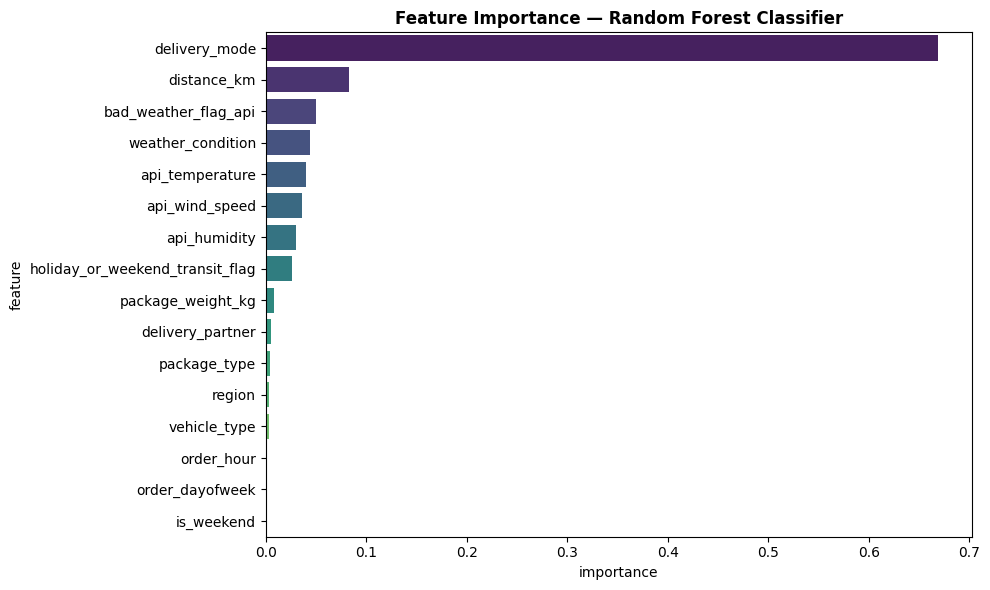

                        feature  importance
                  delivery_mode    0.669177
                    distance_km    0.082199
           bad_weather_flag_api    0.050153
              weather_condition    0.043409
                api_temperature    0.039747
                 api_wind_speed    0.035778
                   api_humidity    0.030199
holiday_or_weekend_transit_flag    0.026166
              package_weight_kg    0.007779
               delivery_partner    0.005000
                   package_type    0.003797
                         region    0.003577
                   vehicle_type    0.003020
                     order_hour    0.000000
                order_dayofweek    0.000000
                     is_weekend    0.000000


In [12]:
# ============================================================
# STEP 10 — FEATURE IMPORTANCE
# ============================================================

feat_imp = pd.DataFrame({
    'feature':    X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance — Random Forest Classifier', fontweight='bold')
plt.tight_layout()
plt.savefig('../Results/rf_classification_feat_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print(feat_imp.to_string(index=False))

In [13]:
# ============================================================
# STEP 11 — SAVE MODEL, SCALER, ENCODERS & FEATURE LIST
#
# Saved under ../models/ :
#   classification_model.pkl           ← trained RandomForestClassifier
#   classification_scaler.pkl          ← fitted StandardScaler
#   classification_label_encoders.pkl  ← dict of {col: LabelEncoder}
#   classification_features.pkl        ← ordered list of feature names
# ============================================================

with open('../models/classification_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../models/classification_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/classification_label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Save the exact feature order — critical so inference uses the same column order
with open('../models/classification_features.pkl', 'wb') as f:
    pickle.dump(SAFE_FEATURES, f)

print('[SAVED] All artifacts written to ../models/')
print('  → classification_model.pkl')
print('  → classification_scaler.pkl')
print('  → classification_label_encoders.pkl')
print('  → classification_features.pkl')

[SAVED] All artifacts written to ../models/
  → classification_model.pkl
  → classification_scaler.pkl
  → classification_label_encoders.pkl
  → classification_features.pkl


In [38]:
# ============================================================
# CUSTOM INPUT PREDICTION (INFERENCE)
# ============================================================

import pandas as pd
import numpy as np
import pickle

# -----------------------------
# LOAD SAVED ARTIFACTS
# -----------------------------
with open('../models/classification_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../models/classification_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../models/classification_label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

with open('../models/classification_features.pkl', 'rb') as f:
    feature_list = pickle.load(f)

print("[OK] Model & artifacts loaded")


# -----------------------------
# GIVE CUSTOM INPUT HERE
# -----------------------------
sample_input = {
    "delivery_partner": "dhl",
    "package_type": "fragile",
    "vehicle_type": "bike",
    "delivery_mode": "express",
    "region": "urban",
    "weather_condition": "storm",
    "distance_km": 18,
    "package_weight_kg": 3,
    "api_temperature": 26,
    "api_humidity": 90,
    "api_wind_speed": 25,
    "bad_weather_flag_api": 1,
    "holiday_or_weekend_transit_flag": 1,
    "order_hour": 22,
    "order_dayofweek": 6,
    "is_weekend": 1
}

# -----------------------------
# CONVERT TO DATAFRAME
# -----------------------------
input_df = pd.DataFrame([sample_input])

# Ensure same feature order
input_df = input_df[feature_list]

# -----------------------------
# APPLY LABEL ENCODING
# -----------------------------
for col, le in label_encoders.items():
    if col in input_df.columns:
        input_df[col] = input_df[col].astype(str)
        # Handle unseen labels safely
        input_df[col] = input_df[col].map(
            lambda x: le.transform([x])[0] if x in le.classes_ else 0
        )

# Convert to numeric
input_df = input_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# -----------------------------
# SCALING
# -----------------------------
input_scaled = scaler.transform(input_df)

# -----------------------------
# PREDICTION
# -----------------------------
pred = model.predict(input_scaled)[0]
prob = model.predict_proba(input_scaled)[0][1]

# -----------------------------
# OUTPUT
# -----------------------------
label = "Delayed" if pred == 1 else "On-Time"

print("\n🔮 Prediction Result:")
print(f"Prediction : {label}")
print(f"Delay Probability : {prob:.4f}")

[OK] Model & artifacts loaded

🔮 Prediction Result:
Prediction : Delayed
Delay Probability : 0.8484
